# 06 — Évaluation expérimentale locale

Ce notebook est destiné à être exécuté **sur le PC local avec ArangoDB `YelpDB` accessible**.

Les 256 générations ont déjà été produites sur Kaggle et sont chargées depuis :

`results/generated_queries.csv`

Ce notebook **ne relance ni RAG, ni Ollama, ni génération LLM**.

Pipeline évalué :

`AQL généré → validation → confidentialité → exécution contrôlée → Gold AQL → comparaison → métriques`


## 1. Imports et chemins du projet

Le notebook cherche automatiquement la racine `LLM_Yelp_Project`.


In [3]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

current = Path.cwd().resolve()

candidates = [
    current,
    current / "LLM_Yelp_Project",
    current.parent,
]

PROJECT_ROOT = None

for candidate in candidates:
    if (
        (candidate / "arangodb" / "schema_description.json").exists()
        and
        (candidate / "data" / "benchmark" / "yelp_benchmark.json").exists()
    ):
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Racine LLM_Yelp_Project introuvable. "
        "Ouvrez le notebook depuis le projet ou adaptez candidates."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SCHEMA_PATH = PROJECT_ROOT / "arangodb" / "schema_description.json"
BENCHMARK_PATH = PROJECT_ROOT / "data" / "benchmark" / "yelp_benchmark.json"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GENERATED_PATH = RESULTS_DIR / "generated_queries.csv"
EXECUTION_PATH = RESULTS_DIR / "execution_results.csv"
METRICS_PATH = RESULTS_DIR / "metrics.csv"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("GENERATED_PATH :", GENERATED_PATH)
print("EXECUTION_PATH :", EXECUTION_PATH)
print("METRICS_PATH :", METRICS_PATH)


PROJECT_ROOT : C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project
GENERATED_PATH : C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project\results\generated_queries.csv
EXECUTION_PATH : C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project\results\execution_results.csv
METRICS_PATH : C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project\results\metrics.csv


## 2. Chargement du benchmark et des 256 générations


In [2]:
with open(BENCHMARK_PATH, "r", encoding="utf-8") as f:
    benchmark = json.load(f)

assert len(benchmark) == 128, f"Benchmark inattendu : {len(benchmark)} questions"

benchmark_by_id = {
    str(item["id"]): item
    for item in benchmark
}

if not GENERATED_PATH.exists():
    raise FileNotFoundError(
        f"{GENERATED_PATH} introuvable. "
        "Copiez d'abord le CSV final généré sur Kaggle dans results/."
    )

generated_df = pd.read_csv(GENERATED_PATH)

required_columns = {
    "question_id",
    "model",
    "generated_aql",
}

missing = required_columns - set(generated_df.columns)
if missing:
    raise KeyError(
        f"Colonnes manquantes dans generated_queries.csv : {sorted(missing)}"
    )

generated_df["question_id"] = generated_df["question_id"].astype(str)
generated_df["model"] = generated_df["model"].astype(str)

# Compatibilité avec le nom réellement produit sur Kaggle.
if "generation_time" not in generated_df.columns:
    generated_df["generation_time"] = pd.NA

if "generation_error" not in generated_df.columns:
    generated_df["generation_error"] = pd.NA

print("Nombre de lignes :", len(generated_df))
print("\nQuestions par modèle :")
print(generated_df.groupby("model")["question_id"].nunique())

print("\nErreurs de génération :")
print(generated_df["generation_error"].notna().sum())

duplicates = generated_df.duplicated(
    subset=["model", "question_id"],
    keep=False
).sum()

print("\nDoublons modèle-question :", duplicates)

display(
    generated_df[
        [
            "question_id",
            "model",
            "model_name",
            "generated_aql",
            "generation_time",
            "generation_error",
        ]
    ].head()
)


Nombre de lignes : 256

Questions par modèle :
model
DeepSeek-Coder    128
Mistral           128
Name: question_id, dtype: int64

Erreurs de génération :
0

Doublons modèle-question : 0


,question_id,model,model_name,generated_aql,generation_time,generation_error
0,Q001,Mistral,mistral:latest,FOR b IN Businesses\n LET categories = (\n ...,8.247131,NaN
1,Q002,Mistral,mistral:latest,"FOR b IN Businesses\n FILTER b.city == ""Los...",14.496274,NaN
2,Q003,Mistral,mistral:latest,LET preschools = (\n FOR b IN Businesses\n ...,3.914270,NaN
3,Q004,Mistral,mistral:latest,FOR b IN Businesses\nFILTER b.rating > 3.5\nRE...,1.793947,NaN
4,Q005,Mistral,mistral:latest,FOR b IN Businesses\nFILTER b.rating > 4.5\nRE...,2.858483,NaN


### Contrôle attendu

Le résultat final doit contenir :

- 256 lignes ;
- 128 questions pour `Mistral` ;
- 128 questions pour `DeepSeek-Coder` ;
- 0 erreur de génération ;
- 0 doublon `(model, question_id)`.


In [3]:
expected_pairs = 128 * 2

assert len(generated_df) == expected_pairs, \
    f"256 lignes attendues, {len(generated_df)} trouvées."

assert generated_df[["model", "question_id"]].drop_duplicates().shape[0] == expected_pairs, \
    "Les 256 couples modèle-question ne sont pas uniques."

assert generated_df["generation_error"].notna().sum() == 0, \
    "Le fichier contient encore des erreurs de génération."

print("Contrôle du CSV généré : OK")


Contrôle du CSV généré : OK


## 3. Initialisation du pipeline d'évaluation

Cette partie utilise uniquement les modules du projet : validation, confidentialité, exécution et évaluation.


In [12]:
from src.query_validator import QueryValidator
from src.privacy_filter import PrivacyFilter
from src.query_executor import QueryExecutor
from src.evaluator import Evaluator
from src.db_connector import get_database

validator = QueryValidator(SCHEMA_PATH)
privacy_filter = PrivacyFilter()

print("QueryValidator et PrivacyFilter prêts.")


QueryValidator et PrivacyFilter prêts.


## 4. Connexion à ArangoDB `YelpDB`

Adaptez uniquement `host`, `username` ou `password` si votre installation locale est différente.


In [16]:
db = get_database(
    host="http://localhost:8529",
    database="YelpDB",
    username="root",
    password="root",
)

executor = QueryExecutor(db, validator)
evaluator = Evaluator(db)

print("Connexion à YelpDB prête.")


Connexion à YelpDB prête.


## 5. Fonctions d'évaluation

L'évaluation est sauvegardée progressivement dans `results/execution_results.csv`.

Si le notebook est interrompu, la fonction peut reprendre les couples `(model, question_id)` déjà évalués.


In [8]:
def _safe_text(value):
    if value is None or pd.isna(value):
        return ""
    return str(value)


def classify_error(
    validation,
    privacy,
    execution,
    gold_execution,
    functional_correct,
    generation_error=None,
):
    if generation_error is not None and _safe_text(generation_error).strip():
        return "generation_error"

    if not validation.get("valid", False):
        errors = " ".join(validation.get("errors", [])).lower()

        if "unknown collection" in errors:
            return "unknown_collection"

        if "unknown attribute" in errors:
            return "unknown_attribute"

        if "forbidden operation" in errors:
            return "forbidden_operation"

        return "validation_error"

    if not privacy.get("allowed", False):
        return "privacy_blocked"

    if not execution.get("executed", False):
        return "execution_error"

    if not gold_execution.get("success", False):
        return "gold_execution_error"

    if functional_correct is False:
        return "semantic_result_mismatch"

    return "correct"


def evaluate_one_row(row):
    qid = str(row["question_id"])
    model = str(row["model"])

    if qid not in benchmark_by_id:
        raise KeyError(f"{qid} absent du benchmark.")

    item = benchmark_by_id[qid]

    generated_aql = _safe_text(row.get("generated_aql", ""))
    generation_error = row.get("generation_error", None)

    if pd.isna(generation_error):
        generation_error = None

    validation = validator.validate(generated_aql)
    privacy = privacy_filter.check(generated_aql)

    if validation.get("valid", False) and privacy.get("allowed", False):
        execution = executor.execute(generated_aql)
    else:
        execution = {
            "executed": False,
            "results": None,
            "error": (
                "Blocked by PrivacyFilter"
                if not privacy.get("allowed", False)
                else "Rejected by validator"
            ),
        }

    gold_execution = evaluator.execute_query(item["gold_aql"])

    functional_correct = False

    if (
        gold_execution.get("success", False)
        and execution.get("executed", False)
    ):
        functional_correct = evaluator.compare_results(
            gold_execution.get("results", []),
            execution.get("results", []),
        )

    error_category = classify_error(
        validation=validation,
        privacy=privacy,
        execution=execution,
        gold_execution=gold_execution,
        functional_correct=functional_correct,
        generation_error=generation_error,
    )

    generated_results = execution.get("results")
    gold_results = gold_execution.get("results")

    return {
        "question_id": qid,
        "question": item["question"],
        "difficulty": item.get("difficulty", ""),
        "question_type": item.get("type", ""),
        "intent": item.get("intent", ""),
        "comparison_method": item.get("comparison_method", ""),
        "model": model,
        "model_name": row.get("model_name", ""),
        "generated_aql": generated_aql,
        "gold_aql": item["gold_aql"],
        "generation_time": row.get("generation_time", None),
        "generation_error": generation_error,
        "validation_valid": bool(validation.get("valid", False)),
        "validation_errors": " | ".join(validation.get("errors", [])),
        "validation_warnings": " | ".join(validation.get("warnings", [])),
        "privacy_allowed": bool(privacy.get("allowed", False)),
        "sensitive_fields": " | ".join(privacy.get("sensitive_fields", [])),
        "executed": bool(execution.get("executed", False)),
        "execution_error": execution.get("error"),
        "gold_executed": bool(gold_execution.get("success", False)),
        "gold_execution_error": gold_execution.get("error"),
        "gold_result_count": (
            len(gold_results)
            if gold_execution.get("success", False)
            and gold_results is not None
            else None
        ),
        "generated_result_count": (
            len(generated_results)
            if execution.get("executed", False)
            and generated_results is not None
            else None
        ),
        "functional_correct": bool(functional_correct),
        "error_category": error_category,
    }


def evaluate_generated_rows(generated_dataframe, resume=True):
    if resume and EXECUTION_PATH.exists():
        existing = pd.read_csv(EXECUTION_PATH)

        if {"model", "question_id"}.issubset(existing.columns):
            existing["question_id"] = existing["question_id"].astype(str)
            existing["model"] = existing["model"].astype(str)

            rows = existing.to_dict("records")
            completed = set(
                zip(existing["model"], existing["question_id"])
            )

            print(
                f"Reprise : {len(completed)} évaluations déjà présentes."
            )
        else:
            rows = []
            completed = set()
            print(
                "Ancien execution_results.csv incompatible : "
                "nouvelle évaluation."
            )
    else:
        rows = []
        completed = set()

    total = len(generated_dataframe)

    for _, row in generated_dataframe.iterrows():
        key = (
            str(row["model"]),
            str(row["question_id"]),
        )

        if key in completed:
            continue

        print(
            f"[{len(completed) + 1}/{total}] "
            f"{row['model']} - {row['question_id']}"
        )

        try:
            result_row = evaluate_one_row(row)
        except Exception as exc:
            qid = str(row["question_id"])
            item = benchmark_by_id.get(qid, {})

            result_row = {
                "question_id": qid,
                "question": item.get("question", row.get("question", "")),
                "difficulty": item.get("difficulty", ""),
                "question_type": item.get("type", ""),
                "intent": item.get("intent", ""),
                "comparison_method": item.get("comparison_method", ""),
                "model": str(row["model"]),
                "model_name": row.get("model_name", ""),
                "generated_aql": _safe_text(row.get("generated_aql", "")),
                "gold_aql": item.get("gold_aql", ""),
                "generation_time": row.get("generation_time", None),
                "generation_error": row.get("generation_error", None),
                "validation_valid": False,
                "validation_errors": "",
                "validation_warnings": "",
                "privacy_allowed": False,
                "sensitive_fields": "",
                "executed": False,
                "execution_error": f"Evaluation exception: {exc}",
                "gold_executed": False,
                "gold_execution_error": None,
                "gold_result_count": None,
                "generated_result_count": None,
                "functional_correct": False,
                "error_category": "evaluation_exception",
            }

        rows.append(result_row)
        completed.add(key)

        pd.DataFrame(rows).to_csv(
            EXECUTION_PATH,
            index=False,
            encoding="utf-8",
        )

    final_df = pd.DataFrame(rows)

    final_df = (
        final_df
        .drop_duplicates(
            subset=["model", "question_id"],
            keep="last",
        )
        .reset_index(drop=True)
    )

    final_df.to_csv(
        EXECUTION_PATH,
        index=False,
        encoding="utf-8",
    )

    return final_df


## 6. Lancer l'évaluation locale des 256 générations

Exécutez cette cellule lorsque `YelpDB` fonctionne.

La sauvegarde progressive permet de reprendre après une interruption.


In [7]:
evaluation_df = evaluate_generated_rows(
    generated_df,
    resume=True,
)

print("\nÉvaluation terminée.")
print("Lignes évaluées :", len(evaluation_df))

print("\nQuestions évaluées par modèle :")
print(
    evaluation_df
    .groupby("model")["question_id"]
    .nunique()
)


[1/256] Mistral - Q001
[2/256] Mistral - Q002
[3/256] Mistral - Q003
[4/256] Mistral - Q004
[5/256] Mistral - Q005
[6/256] Mistral - Q006
[7/256] Mistral - Q007
[8/256] Mistral - Q008
[9/256] Mistral - Q009
[10/256] Mistral - Q010
[11/256] Mistral - Q011
[12/256] Mistral - Q012
[13/256] Mistral - Q013
[14/256] Mistral - Q014
[15/256] Mistral - Q015
[16/256] Mistral - Q016
[17/256] Mistral - Q017
[18/256] Mistral - Q018
[19/256] Mistral - Q019
[20/256] Mistral - Q020
[21/256] Mistral - Q021
[22/256] Mistral - Q022
[23/256] Mistral - Q023
[24/256] Mistral - Q024
[25/256] Mistral - Q025
[26/256] Mistral - Q026
[27/256] Mistral - Q027
[28/256] Mistral - Q028
[29/256] Mistral - Q029
[30/256] Mistral - Q030
[31/256] Mistral - Q031
[32/256] Mistral - Q032
[33/256] Mistral - Q033
[34/256] Mistral - Q034
[35/256] Mistral - Q035
[36/256] Mistral - Q036
[37/256] Mistral - Q037
[38/256] Mistral - Q038
[39/256] Mistral - Q039
[40/256] Mistral - Q040
[41/256] Mistral - Q041
[42/256] Mistral - Q042
[

## 7. Recharger les résultats d'exécution

Cette cellule permet aussi de reprendre l'analyse après avoir fermé puis rouvert le notebook.


In [8]:
if not EXECUTION_PATH.exists():
    raise FileNotFoundError(
        "execution_results.csv absent. "
        "Exécutez d'abord la cellule d'évaluation."
    )

evaluation_df = pd.read_csv(EXECUTION_PATH)

evaluation_df["question_id"] = evaluation_df["question_id"].astype(str)
evaluation_df["model"] = evaluation_df["model"].astype(str)

print("Lignes évaluées :", len(evaluation_df))

print("\nPar modèle :")
print(
    evaluation_df
    .groupby("model")["question_id"]
    .nunique()
)

print("\nCatégories d'erreurs :")
print(evaluation_df["error_category"].value_counts(dropna=False))

display(evaluation_df.head())


Lignes évaluées : 256

Par modèle :
model
DeepSeek-Coder    128
Mistral           128
Name: question_id, dtype: int64

Catégories d'erreurs :
error_category
correct                     106
semantic_result_mismatch     51
execution_error              51
privacy_blocked              22
unknown_attribute            16
unknown_collection            9
forbidden_operation           1
Name: count, dtype: int64


,question_id,question,difficulty,question_type,intent,comparison_method,model,model_name,generated_aql,gold_aql,...,privacy_allowed,sensitive_fields,executed,execution_error,gold_executed,gold_execution_error,gold_result_count,generated_result_count,functional_correct,error_category
0,Q001,Give me all the moroccan restaurants in Texas,medium,graph_filter,NaN,NaN,Mistral,mistral:latest,FOR b IN Businesses\n LET categories = (\n ...,"\nFOR b IN Businesses\n FILTER b.state == ""...",...,True,NaN,True,NaN,True,NaN,0.0,0.0,True,correct
1,Q002,List all the Italian restaurants in Los Angeles,medium,graph_filter,NaN,NaN,Mistral,mistral:latest,"FOR b IN Businesses\n FILTER b.city == ""Los...","\nFOR b IN Businesses\n FILTER b.city == ""L...",...,True,NaN,True,NaN,True,NaN,0.0,0.0,True,correct
2,Q003,find the number of preschools in Madison,medium,graph_count,NaN,NaN,Mistral,mistral:latest,LET preschools = (\n FOR b IN Businesses\n ...,\nLET preschools = (\n FOR b IN Businesses\...,...,True,NaN,True,NaN,True,NaN,1.0,1.0,False,semantic_result_mismatch
3,Q004,List all the restaurants rated more than 3.5,medium,graph_filter,NaN,NaN,Mistral,mistral:latest,FOR b IN Businesses\nFILTER b.rating > 3.5\nRE...,\nFOR b IN Businesses\n FILTER b.rating > 3...,...,True,NaN,True,NaN,True,NaN,10605.0,44066.0,False,semantic_result_mismatch
4,Q005,List all the businesses with more than 4.5 stars,simple,document_filter,NaN,NaN,Mistral,mistral:latest,FOR b IN Businesses\nFILTER b.rating > 4.5\nRE...,\nFOR b IN Businesses\n FILTER b.rating > 4...,...,True,NaN,True,NaN,True,NaN,12964.0,12964.0,True,correct


## 8. Métriques finales par modèle


In [9]:
def summarize_model(group):
    total = len(group)

    return {
        "questions": total,
        "generated": int(
            group["generated_aql"]
            .fillna("")
            .str.strip()
            .ne("")
            .sum()
        ),
        "validation_valid": int(group["validation_valid"].sum()),
        "validation_rate_%": round(
            group["validation_valid"].mean() * 100,
            2,
        ),
        "privacy_allowed": int(group["privacy_allowed"].sum()),
        "privacy_allowed_rate_%": round(
            group["privacy_allowed"].mean() * 100,
            2,
        ),
        "executed": int(group["executed"].sum()),
        "execution_rate_%": round(
            group["executed"].mean() * 100,
            2,
        ),
        "gold_executed": int(group["gold_executed"].sum()),
        "gold_execution_rate_%": round(
            group["gold_executed"].mean() * 100,
            2,
        ),
        "functional_correct": int(group["functional_correct"].sum()),
        "functional_accuracy_%": round(
            group["functional_correct"].mean() * 100,
            2,
        ),
        "avg_generation_time_s": round(
            pd.to_numeric(
                group["generation_time"],
                errors="coerce",
            ).mean(),
            2,
        ),
        "median_generation_time_s": round(
            pd.to_numeric(
                group["generation_time"],
                errors="coerce",
            ).median(),
            2,
        ),
    }


metrics_rows = []

for model, group in evaluation_df.groupby("model", sort=False):
    row = {"model": model}
    row.update(summarize_model(group))
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)

metrics_df.to_csv(
    METRICS_PATH,
    index=False,
    encoding="utf-8",
)

display(metrics_df)

print("Métriques sauvegardées :", METRICS_PATH)


,model,questions,generated,validation_valid,validation_rate_%,privacy_allowed,privacy_allowed_rate_%,executed,execution_rate_%,gold_executed,gold_execution_rate_%,functional_correct,functional_accuracy_%,avg_generation_time_s,median_generation_time_s
0,Mistral,128,128,110,85.94,116,90.62,64,50.00,124,96.88,42,32.81,4.79,4.22
1,DeepSeek-Coder,128,128,120,93.75,115,89.84,93,72.66,124,96.88,64,50.00,3.73,3.62


Métriques sauvegardées : C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project\results\metrics.csv


## 9. Résultats par difficulté


In [10]:
by_difficulty = (
    evaluation_df
    .groupby(
        ["model", "difficulty"],
        dropna=False,
    )
    .agg(
        questions=("question_id", "count"),
        validation_rate=("validation_valid", "mean"),
        execution_rate=("executed", "mean"),
        functional_accuracy=("functional_correct", "mean"),
    )
    .reset_index()
)

for col in [
    "validation_rate",
    "execution_rate",
    "functional_accuracy",
]:
    by_difficulty[col] = (
        by_difficulty[col] * 100
    ).round(2)

display(by_difficulty)


,model,difficulty,questions,validation_rate,execution_rate,functional_accuracy
0,DeepSeek-Coder,advanced,36,91.67,69.44,41.67
1,DeepSeek-Coder,complex,18,83.33,38.89,22.22
2,DeepSeek-Coder,medium,54,96.30,85.19,62.96
3,DeepSeek-Coder,simple,20,100.00,75.00,55.00
4,Mistral,advanced,36,86.11,41.67,30.56
5,Mistral,complex,18,61.11,27.78,16.67
6,Mistral,medium,54,88.89,57.41,37.04
7,Mistral,simple,20,100.00,65.00,40.00


## 10. Résultats par type de question


In [11]:
by_type = (
    evaluation_df
    .groupby(
        ["model", "question_type"],
        dropna=False,
    )
    .agg(
        questions=("question_id", "count"),
        validation_rate=("validation_valid", "mean"),
        execution_rate=("executed", "mean"),
        functional_accuracy=("functional_correct", "mean"),
    )
    .reset_index()
)

for col in [
    "validation_rate",
    "execution_rate",
    "functional_accuracy",
]:
    by_type[col] = (
        by_type[col] * 100
    ).round(2)

display(by_type)


,model,question_type,questions,validation_rate,execution_rate,functional_accuracy
0,DeepSeek-Coder,category_filter,1,100.00,100.00,100.00
1,DeepSeek-Coder,document_aggregation,1,100.00,100.00,100.00
2,DeepSeek-Coder,document_count,5,100.00,80.00,40.00
3,DeepSeek-Coder,document_count_distinct,1,100.00,0.00,0.00
4,DeepSeek-Coder,document_filter,8,100.00,62.50,50.00
...,...,...,...,...,...,...
59,Mistral,multi_hop_graph_filter,7,71.43,42.86,28.57
60,Mistral,multi_relation_graph,2,100.00,0.00,0.00
61,Mistral,multi_relation_graph_count,2,100.00,50.00,0.00
62,Mistral,multi_relation_graph_filter,2,100.00,100.00,100.00


## 11. Matrice des erreurs


In [13]:
error_matrix = (
    evaluation_df
    .groupby(
        ["model", "error_category"],
        dropna=False,
    )
    .size()
    .unstack(fill_value=0)
)

display(error_matrix)


error_category,correct,execution_error,forbidden_operation,privacy_blocked,semantic_result_mismatch,unknown_attribute,unknown_collection
model,,,,,,,
DeepSeek-Coder,64,16,1,11,29,6,1
Mistral,42,35,0,11,22,10,8


## 12. Graphiques finaux

Chaque graphique est enregistré séparément dans `results/figures/`.


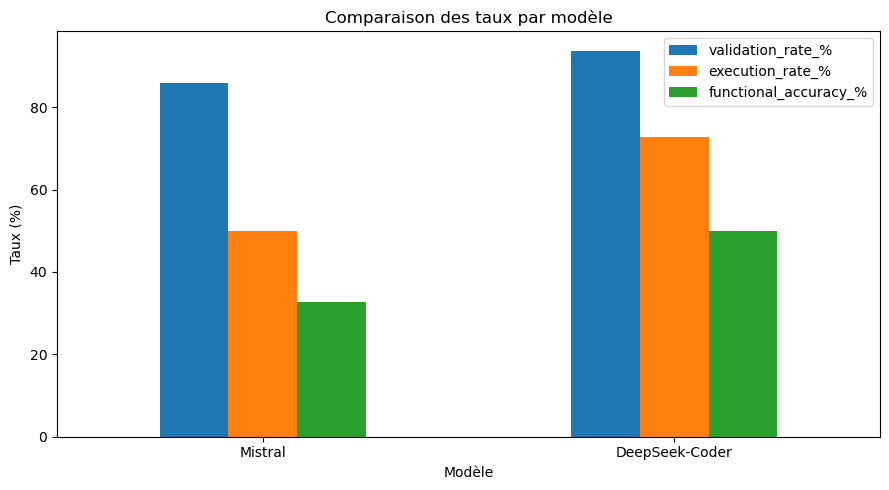

Sauvegardé : C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project\results\figures\model_rates_comparison.png


In [14]:
rate_table = (
    metrics_df
    .set_index("model")
    [
        [
            "validation_rate_%",
            "execution_rate_%",
            "functional_accuracy_%",
        ]
    ]
)

ax = rate_table.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title("Comparaison des taux par modèle")
ax.set_ylabel("Taux (%)")
ax.set_xlabel("Modèle")

plt.xticks(rotation=0)
plt.tight_layout()

figure_path = FIGURES_DIR / "model_rates_comparison.png"
plt.savefig(figure_path, dpi=200)
plt.show()

print("Sauvegardé :", figure_path)


In [ ]:
ax = (
    metrics_df
    .set_index("model")
    ["avg_generation_time_s"]
    .plot(
        kind="bar",
        figsize=(7, 5),
    )
)

ax.set_title("Temps moyen de génération")
ax.set_ylabel("Secondes")
ax.set_xlabel("Modèle")

plt.xticks(rotation=0)
plt.tight_layout()

figure_path = FIGURES_DIR / "average_generation_time.png"
plt.savefig(figure_path, dpi=200)
plt.show()

print("Sauvegardé :", figure_path)


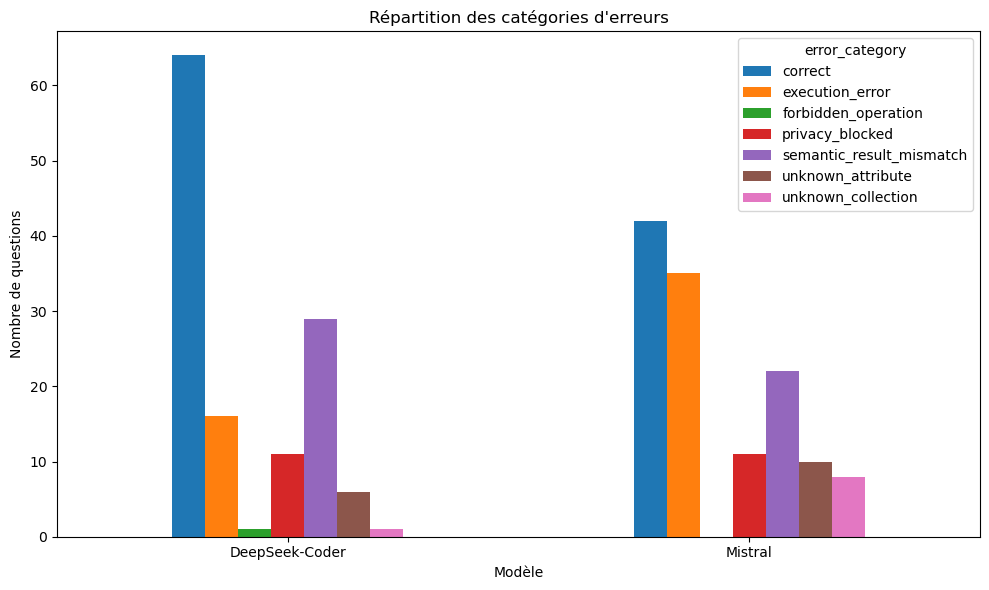

Sauvegardé : C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project\results\figures\error_matrix.png


In [16]:
ax = error_matrix.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_title("Répartition des catégories d'erreurs")
ax.set_ylabel("Nombre de questions")
ax.set_xlabel("Modèle")

plt.xticks(rotation=0)
plt.tight_layout()

figure_path = FIGURES_DIR / "error_matrix.png"
plt.savefig(figure_path, dpi=200)
plt.show()

print("Sauvegardé :", figure_path)


## 13. Vérifications finales


In [17]:
expected = 256

generated_pairs = (
    generated_df[
        ["model", "question_id"]
    ]
    .drop_duplicates()
    .shape[0]
)

evaluated_pairs = (
    evaluation_df[
        ["model", "question_id"]
    ]
    .drop_duplicates()
    .shape[0]
)

print("Générations attendues :", expected)
print("Couples générés :", generated_pairs)
print("Couples évalués :", evaluated_pairs)

assert generated_pairs == expected, \
    f"{expected} couples générés attendus."

assert evaluated_pairs == expected, \
    f"{expected} couples évalués attendus."

print("\nVérification finale réussie : 128 questions × 2 modèles.")

print("\nFichiers finaux :")
print("-", GENERATED_PATH)
print("-", EXECUTION_PATH)
print("-", METRICS_PATH)

print("\nFigures :")
for path in sorted(FIGURES_DIR.glob("*.png")):
    print("-", path)


Générations attendues : 256
Couples générés : 256
Couples évalués : 256

Vérification finale réussie : 128 questions × 2 modèles.

Fichiers finaux :
- C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project\results\generated_queries.csv
- C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project\results\execution_results.csv
- C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project\results\metrics.csv

Figures :
- C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project\results\figures\error_matrix.png
- C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project\results\figures\model_rates_comparison.png


## 14. Point méthodologique à commenter dans le rapport

L'analyse finale doit distinguer :

- la validité syntaxique / structurelle de l'AQL ;
- l'exécutabilité dans ArangoDB ;
- la confidentialité ;
- la correction fonctionnelle par comparaison avec le Gold ;
- les temps de génération ;
- la robustesse selon la difficulté et le type de question ;
- les catégories d'erreurs.

**Limite importante :** une égalité de résultats, notamment lorsque les deux requêtes retournent un résultat vide, ne prouve pas nécessairement une équivalence sémantique parfaite. Cette limite doit être signalée dans l'analyse expérimentale.


In [4]:
# ============================================================
# 15.1 CHARGEMENT DES RÉSULTATS AGENT
# ============================================================

AGENT_MISTRAL_PATH = (
    RESULTS_DIR / "agent_mistral_results.csv"
)

AGENT_DEEPSEEK_PATH = (
    RESULTS_DIR / "agent_deepseek_results.csv"
)

AGENT_EXECUTION_PATH = (
    RESULTS_DIR / "agent_execution_results.csv"
)

AGENT_METRICS_PATH = (
    RESULTS_DIR / "agent_functional_metrics.csv"
)

COMPARISON_PATH = (
    RESULTS_DIR / "direct_vs_agent_final.csv"
)


for path in [
    AGENT_MISTRAL_PATH,
    AGENT_DEEPSEEK_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Fichier absent : {path}"
        )


agent_mistral_raw = pd.read_csv(
    AGENT_MISTRAL_PATH
)

agent_deepseek_raw = pd.read_csv(
    AGENT_DEEPSEEK_PATH
)


# On impose les mêmes labels que dans l'évaluation directe
agent_mistral_raw["model"] = "Mistral"

agent_deepseek_raw["model"] = (
    "DeepSeek-Coder"
)


agent_raw_df = pd.concat(
    [
        agent_mistral_raw,
        agent_deepseek_raw,
    ],
    ignore_index=True,
)


agent_raw_df[
    "question_id"
] = (
    agent_raw_df[
        "question_id"
    ]
    .astype(str)
)


print(
    "Nombre total de résultats Agent :",
    len(agent_raw_df)
)

print("\nPar modèle :")
print(
    agent_raw_df
    .groupby("model")["question_id"]
    .count()
)

print("\nColonnes :")
print(agent_raw_df.columns.tolist())

Nombre total de résultats Agent : 256

Par modèle :
model
DeepSeek-Coder    128
Mistral           128
Name: question_id, dtype: int64

Colonnes :
['question_id', 'question', 'model', 'original_aql', 'final_aql', 'valid', 'corrected', 'correction_attempts', 'generation_time', 'validation_errors', 'validation_warnings', 'privacy_allowed', 'privacy_reason', 'history', 'generation_error']


In [5]:
from pathlib import Path
import pandas as pd

AGENT_MISTRAL_PATH = (
    RESULTS_DIR / "agent_mistral_results.csv"
)

AGENT_DEEPSEEK_PATH = (
    RESULTS_DIR / "agent_deepseek_results.csv"
)

print("Mistral existe  :", AGENT_MISTRAL_PATH.exists())
print("DeepSeek existe :", AGENT_DEEPSEEK_PATH.exists())

agent_mistral_df = pd.read_csv(
    AGENT_MISTRAL_PATH
)

agent_deepseek_df = pd.read_csv(
    AGENT_DEEPSEEK_PATH
)

print("\nMistral :", len(agent_mistral_df))
print("DeepSeek:", len(agent_deepseek_df))

print("\nColonnes Mistral :")
print(agent_mistral_df.columns.tolist())

print("\nColonnes DeepSeek :")
print(agent_deepseek_df.columns.tolist())

Mistral existe  : True
DeepSeek existe : True

Mistral : 128
DeepSeek: 128

Colonnes Mistral :
['question_id', 'question', 'model', 'original_aql', 'final_aql', 'valid', 'corrected', 'correction_attempts', 'generation_time', 'validation_errors', 'validation_warnings', 'privacy_allowed', 'privacy_reason', 'history', 'generation_error']

Colonnes DeepSeek :
['question_id', 'question', 'model', 'original_aql', 'final_aql', 'valid', 'corrected', 'correction_attempts', 'generation_time', 'validation_errors', 'validation_warnings', 'privacy_allowed', 'privacy_reason', 'history', 'generation_error']


In [6]:
# ============================================================
# 15.1 PRÉPARATION DES RÉSULTATS AGENT
# ============================================================

AGENT_EXECUTION_PATH = (
    RESULTS_DIR / "agent_execution_results.csv"
)

AGENT_METRICS_PATH = (
    RESULTS_DIR / "agent_functional_metrics.csv"
)

FINAL_COMPARISON_PATH = (
    RESULTS_DIR / "direct_vs_agent_final.csv"
)


agent_mistral = agent_mistral_df.copy()
agent_deepseek = agent_deepseek_df.copy()


# Labels cohérents avec le notebook 6
agent_mistral["model"] = "Mistral"
agent_deepseek["model"] = "DeepSeek-Coder"


# La fonction evaluate_one_row() attend generated_aql
agent_mistral["generated_aql"] = (
    agent_mistral["final_aql"]
)

agent_deepseek["generated_aql"] = (
    agent_deepseek["final_aql"]
)


# model_name n'existe pas dans les CSV Agent
agent_mistral["model_name"] = "mistral:latest"

agent_deepseek["model_name"] = (
    "deepseek-coder:6.7b"
)


agent_generated_df = pd.concat(
    [
        agent_mistral,
        agent_deepseek,
    ],
    ignore_index=True,
)


agent_generated_df["question_id"] = (
    agent_generated_df["question_id"]
    .astype(str)
)


print("Total :", len(agent_generated_df))

print("\nPar modèle :")
print(
    agent_generated_df
    .groupby("model")["question_id"]
    .nunique()
)

print("\nAQL finales non vides :")
print(
    agent_generated_df
    .groupby("model")["generated_aql"]
    .apply(
        lambda x:
        x.fillna("")
        .str.strip()
        .ne("")
        .sum()
    )
)

Total : 256

Par modèle :
model
DeepSeek-Coder    128
Mistral           128
Name: question_id, dtype: int64

AQL finales non vides :
model
DeepSeek-Coder    128
Mistral           127
Name: generated_aql, dtype: int64


In [10]:
import json

with open(BENCHMARK_PATH, "r", encoding="utf-8") as f:
    benchmark = json.load(f)

assert len(benchmark) == 128

benchmark_by_id = {
    str(item["id"]): item
    for item in benchmark
}

print("Benchmark chargé :", len(benchmark))
print("benchmark_by_id :", len(benchmark_by_id))
print("Exemple :", list(benchmark_by_id.keys())[:5])

Benchmark chargé : 128
benchmark_by_id : 128
Exemple : ['Q001', 'Q002', 'Q003', 'Q004', 'Q005']


In [17]:
# ============================================================
# 15.2 TEST LOCAL : 1 MISTRAL + 1 DEEPSEEK
# ============================================================

test_rows = pd.concat([
    agent_generated_df[
        agent_generated_df["model"] == "Mistral"
    ].head(1),

    agent_generated_df[
        agent_generated_df["model"] == "DeepSeek-Coder"
    ].head(1),
])


for _, row in test_rows.iterrows():

    print("\n" + "=" * 80)
    print(
        row["model"],
        "-",
        row["question_id"]
    )
    print("=" * 80)

    result = evaluate_one_row(row)

    print(
        "Validation :",
        result["validation_valid"]
    )

    print(
        "Privacy    :",
        result["privacy_allowed"]
    )

    print(
        "Exécutée   :",
        result["executed"]
    )

    print(
        "Correcte   :",
        result["functional_correct"]
    )

    print(
        "Catégorie  :",
        result["error_category"]
    )


Mistral - Q001
Validation : True
Privacy    : True
Exécutée   : False
Correcte   : False
Catégorie  : execution_error

DeepSeek-Coder - Q001
Validation : True
Privacy    : True
Exécutée   : False
Correcte   : False
Catégorie  : execution_error


In [18]:
# ============================================================
# DIAGNOSTIC EXECUTION Q001
# ============================================================

test_rows = pd.concat([
    agent_generated_df[
        agent_generated_df["model"] == "Mistral"
    ].head(1),

    agent_generated_df[
        agent_generated_df["model"] == "DeepSeek-Coder"
    ].head(1),
])

for _, row in test_rows.iterrows():

    print("\n" + "=" * 100)
    print(row["model"], "-", row["question_id"])
    print("=" * 100)

    result = evaluate_one_row(row)

    print("\nQUESTION")
    print(row["question"])

    print("\nAQL AGENT")
    print(row["generated_aql"])

    print("\nVALIDATION")
    print("Valid :", result["validation_valid"])
    print("Errors :", result["validation_errors"])

    print("\nEXECUTION")
    print("Executed :", result["executed"])
    print("Execution error :", result["execution_error"])

    print("\nGOLD")
    print("Gold executed :", result["gold_executed"])
    print("Gold error :", result["gold_execution_error"])


Mistral - Q001

QUESTION
Give me all the moroccan restaurants in Texas

AQL AGENT
FOR b IN Businesses
FILTER b.name FILTERED_JSON_OBJECT(@.business_type, 'Restaurants') AND b.state == "Texas"
FILTER b.name FILTERED_JSON_OBJECT(@.category, 'Moroccan')
RETURN b

Here, `FILTERED_JSON_OBJECT` is a custom function that extracts a specific property from the `name` field of the document, assuming that the name of the business follows the pattern: `{business_type} {business_name}`. This pattern allows for easier filtering of specific types of businesses (in this case, restaurants) and categories.

VALIDATION
Valid : True
Errors : 

EXECUTION
Executed : False
Execution error : [HTTP 400][ERR 1501] syntax error, unexpected identifier near 'FILTERED_JSON_OBJECT(@.business_...' at position 2:15

GOLD
Gold executed : True
Gold error : None

DeepSeek-Coder - Q001

QUESTION
Give me all the moroccan restaurants in Texas

AQL AGENT
I'm sorry, but the information you provided seems to be incomplete. Th

In [20]:
# ============================================================
# 15.3 FONCTION D'ÉVALUATION DES REQUÊTES AGENT
# ============================================================

def evaluate_agent_rows(
    agent_dataframe,
    resume=True,
):

    if (
        resume
        and AGENT_EXECUTION_PATH.exists()
    ):

        existing = pd.read_csv(
            AGENT_EXECUTION_PATH
        )

        existing["question_id"] = (
            existing["question_id"]
            .astype(str)
        )

        existing["model"] = (
            existing["model"]
            .astype(str)
        )

        rows = existing.to_dict(
            "records"
        )

        completed = set(
            zip(
                existing["model"],
                existing["question_id"],
            )
        )

        print(
            f"Reprise : {len(completed)} "
            "évaluations Agent déjà présentes."
        )

    else:

        rows = []
        completed = set()

    total = len(agent_dataframe)

    for _, row in agent_dataframe.iterrows():

        model = str(row["model"])
        qid = str(row["question_id"])

        key = (
            model,
            qid,
        )

        if key in completed:
            continue

        print(
            f"[{len(completed)+1}/{total}] "
            f"{model} - {qid}"
        )

        try:

            result_row = evaluate_one_row(row)

            result_row["approach"] = (
                "RAG + Agent"
            )

            result_row["agent_corrected"] = (
                row.get(
                    "corrected",
                    False
                )
            )

            result_row[
                "agent_correction_attempts"
            ] = row.get(
                "correction_attempts",
                0
            )

            result_row["original_aql"] = (
                row.get(
                    "original_aql",
                    ""
                )
            )

            result_row["final_aql"] = (
                row.get(
                    "final_aql",
                    ""
                )
            )

        except Exception as exc:

            item = benchmark_by_id.get(
                qid,
                {}
            )

            result_row = {

                "question_id": qid,

                "question": item.get(
                    "question",
                    row.get(
                        "question",
                        ""
                    )
                ),

                "difficulty": item.get(
                    "difficulty",
                    ""
                ),

                "question_type": item.get(
                    "type",
                    ""
                ),

                "intent": item.get(
                    "intent",
                    ""
                ),

                "comparison_method": item.get(
                    "comparison_method",
                    ""
                ),

                "model": model,

                "model_name": row.get(
                    "model_name",
                    ""
                ),

                "generated_aql": _safe_text(
                    row.get(
                        "generated_aql",
                        ""
                    )
                ),

                "gold_aql": item.get(
                    "gold_aql",
                    ""
                ),

                "generation_time": row.get(
                    "generation_time",
                    None
                ),

                "generation_error": row.get(
                    "generation_error",
                    None
                ),

                "validation_valid": False,

                "validation_errors": "",

                "validation_warnings": "",

                "privacy_allowed": False,

                "sensitive_fields": "",

                "executed": False,

                "execution_error": (
                    f"Evaluation exception: {exc}"
                ),

                "gold_executed": False,

                "gold_execution_error": None,

                "gold_result_count": None,

                "generated_result_count": None,

                "functional_correct": False,

                "error_category": (
                    "evaluation_exception"
                ),

                "approach": "RAG + Agent",

                "agent_corrected": row.get(
                    "corrected",
                    False
                ),

                "agent_correction_attempts":
                    row.get(
                        "correction_attempts",
                        0
                    ),
            }

        rows.append(
            result_row
        )

        completed.add(
            key
        )

        # Sauvegarde après chaque requête
        pd.DataFrame(
            rows
        ).to_csv(
            AGENT_EXECUTION_PATH,
            index=False,
            encoding="utf-8",
        )

    final_df = pd.DataFrame(
        rows
    )

    final_df = (
        final_df
        .drop_duplicates(
            subset=[
                "model",
                "question_id",
            ],
            keep="last",
        )
        .reset_index(
            drop=True
        )
    )

    final_df.to_csv(
        AGENT_EXECUTION_PATH,
        index=False,
        encoding="utf-8",
    )

    return final_df


print("✅ evaluate_agent_rows() définie")

✅ evaluate_agent_rows() définie


In [21]:
# ============================================================
# 15.4 ÉVALUATION FONCTIONNELLE DES 256 SORTIES AGENT
# ============================================================

agent_evaluation_df = evaluate_agent_rows(
    agent_generated_df,
    resume=True
)

print("\n" + "=" * 70)
print("ÉVALUATION AGENT TERMINÉE")
print("=" * 70)

print("Nombre total :", len(agent_evaluation_df))

print("\nNombre par modèle :")
print(
    agent_evaluation_df
    .groupby("model")["question_id"]
    .nunique()
)

print("\nCatégories globales :")
print(
    agent_evaluation_df[
        "error_category"
    ]
    .value_counts()
)

[1/256] Mistral - Q001
[2/256] Mistral - Q002
[3/256] Mistral - Q003
[4/256] Mistral - Q004
[5/256] Mistral - Q005
[6/256] Mistral - Q006
[7/256] Mistral - Q007
[8/256] Mistral - Q008
[9/256] Mistral - Q009
[10/256] Mistral - Q010
[11/256] Mistral - Q011
[12/256] Mistral - Q012
[13/256] Mistral - Q013
[14/256] Mistral - Q014
[15/256] Mistral - Q015
[16/256] Mistral - Q016
[17/256] Mistral - Q017
[18/256] Mistral - Q018
[19/256] Mistral - Q019
[20/256] Mistral - Q020
[21/256] Mistral - Q021
[22/256] Mistral - Q022
[23/256] Mistral - Q023
[24/256] Mistral - Q024
[25/256] Mistral - Q025
[26/256] Mistral - Q026
[27/256] Mistral - Q027
[28/256] Mistral - Q028
[29/256] Mistral - Q029
[30/256] Mistral - Q030
[31/256] Mistral - Q031
[32/256] Mistral - Q032
[33/256] Mistral - Q033
[34/256] Mistral - Q034
[35/256] Mistral - Q035
[36/256] Mistral - Q036
[37/256] Mistral - Q037
[38/256] Mistral - Q038
[39/256] Mistral - Q039
[40/256] Mistral - Q040
[41/256] Mistral - Q041
[42/256] Mistral - Q042
[

In [22]:
# ============================================================
# 16.1 RÉSULTATS FONCTIONNELS FINAUX DE L'AGENT
# ============================================================

agent_summary = (
    agent_evaluation_df
    .groupby("model")
    .agg(
        questions=("question_id", "count"),
        valid_final=("validation_valid", "sum"),
        privacy_allowed=("privacy_allowed", "sum"),
        executed=("executed", "sum"),
        functional_correct=("functional_correct", "sum"),
    )
)

agent_summary["validation_rate_%"] = (
    agent_summary["valid_final"]
    / agent_summary["questions"]
    * 100
).round(2)

agent_summary["privacy_allowed_rate_%"] = (
    agent_summary["privacy_allowed"]
    / agent_summary["questions"]
    * 100
).round(2)

agent_summary["execution_rate_%"] = (
    agent_summary["executed"]
    / agent_summary["questions"]
    * 100
).round(2)

agent_summary["functional_accuracy_%"] = (
    agent_summary["functional_correct"]
    / agent_summary["questions"]
    * 100
).round(2)

display(agent_summary)

,questions,valid_final,privacy_allowed,executed,functional_correct,validation_rate_%,privacy_allowed_rate_%,execution_rate_%,functional_accuracy_%
model,,,,,,,,,
DeepSeek-Coder,128,116,118,89,50,90.62,92.19,69.53,39.06
Mistral,128,117,118,75,47,91.41,92.19,58.59,36.72


In [24]:
# ============================================================
# 16.2 CATÉGORIES D'ERREURS AGENT
# ============================================================

agent_error_counts = (
    agent_evaluation_df
    .groupby(
        ["model", "error_category"]
    )
    .size()
    .unstack(fill_value=0)
)

display(agent_error_counts)

print("\nRépartition globale :")

print(
    agent_evaluation_df[
        "error_category"
    ]
    .value_counts()
)

error_category,correct,execution_error,generation_error,gold_execution_error,privacy_blocked,semantic_result_mismatch,unknown_attribute,unknown_collection
model,,,,,,,,
DeepSeek-Coder,50,18,0,2,9,37,11,1
Mistral,47,34,1,0,8,28,9,1



Répartition globale :
error_category
correct                     97
semantic_result_mismatch    65
execution_error             52
unknown_attribute           20
privacy_blocked             17
unknown_collection           2
gold_execution_error         2
generation_error             1
Name: count, dtype: int64


In [25]:
# ============================================================
# 17. COMPARAISON FINALE RAG DIRECT vs RAG + AGENT
# ============================================================

comparison_rows = []


# Résultats déjà obtenus avec le RAG direct
direct_results = {
    "Mistral": {
        "validation_rate_%": 85.94,
        "execution_rate_%": 50.00,
        "functional_accuracy_%": 32.81,
    },

    "DeepSeek-Coder": {
        "validation_rate_%": 93.75,
        "execution_rate_%": 72.66,
        "functional_accuracy_%": 50.00,
    }
}


for model, values in direct_results.items():

    comparison_rows.append({
        "model": model,
        "approach": "RAG direct",
        **values
    })


for model, row in agent_summary.iterrows():

    comparison_rows.append({
        "model": model,
        "approach": "RAG + Agent",

        "validation_rate_%":
            row["validation_rate_%"],

        "execution_rate_%":
            row["execution_rate_%"],

        "functional_accuracy_%":
            row["functional_accuracy_%"],
    })


final_comparison_df = pd.DataFrame(
    comparison_rows
)

display(
    final_comparison_df
    .sort_values(
        ["model", "approach"]
    )
)


FINAL_COMPARISON_PATH = (
    RESULTS_DIR
    / "direct_vs_agent_final.csv"
)

final_comparison_df.to_csv(
    FINAL_COMPARISON_PATH,
    index=False,
    encoding="utf-8"
)

print(
    "\n✅ Sauvegardé :",
    FINAL_COMPARISON_PATH
)

,model,approach,validation_rate_%,execution_rate_%,functional_accuracy_%
2,DeepSeek-Coder,RAG + Agent,90.62,69.53,39.06
1,DeepSeek-Coder,RAG direct,93.75,72.66,50.00
3,Mistral,RAG + Agent,91.41,58.59,36.72
0,Mistral,RAG direct,85.94,50.00,32.81



✅ Sauvegardé : C:\Users\hp\Desktop\bureau\s8\LLM_Yelp_Project\results\direct_vs_agent_final.csv
